<a href="https://colab.research.google.com/github/albvieiraa/student-alcohol-consumption-ml/blob/main/01_eda_student_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Student Performance & Alcohol Consumption


**Objetivo do projeto:**
Analisar fatores que influenciam o desempenho acadêmico e avaliar a possibilidade de prever a nota final do aluno.

## Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Carregamento dos dados

In [2]:
math_data = 'https://raw.githubusercontent.com/albvieiraa/student-alcohol-consumption-ml/refs/heads/main/data/raw/student-mat.csv'
port_data = 'https://raw.githubusercontent.com/albvieiraa/student-alcohol-consumption-ml/refs/heads/main/data/raw/student-por.csv'

math_df = pd.read_csv(math_data)
port_df = pd.read_csv(port_data)

In [3]:
math_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
port_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## Entendimento inicial dos dados

In [5]:
math_df.shape

(395, 33)

In [6]:
port_df.shape

(649, 33)

In [7]:
math_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
port_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
# verificação de nulos de ambos datasets
#math_df.isnull().sum()
port_df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


## Distribuição da variável alvo - G3

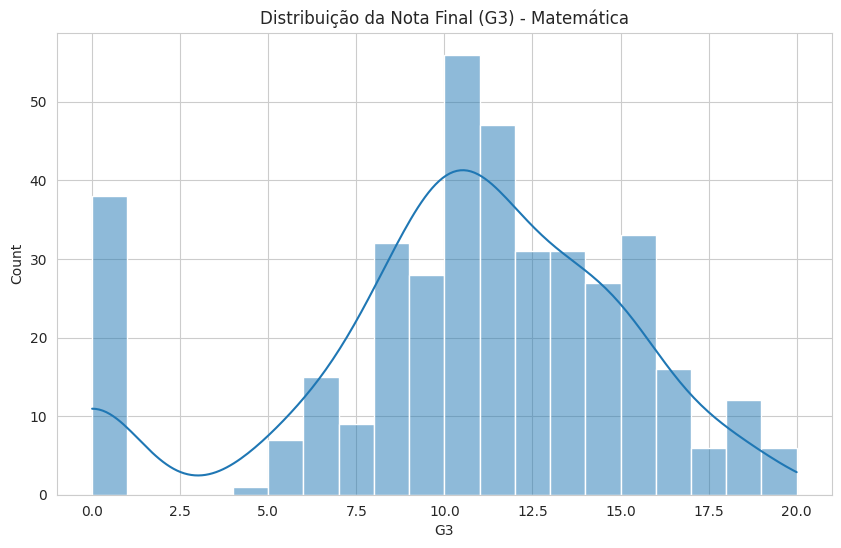

In [10]:
sns.histplot(math_df['G3'], bins=20, kde=True)
plt.title("Distribuição da Nota Final (G3) - Matemática")
plt.show()

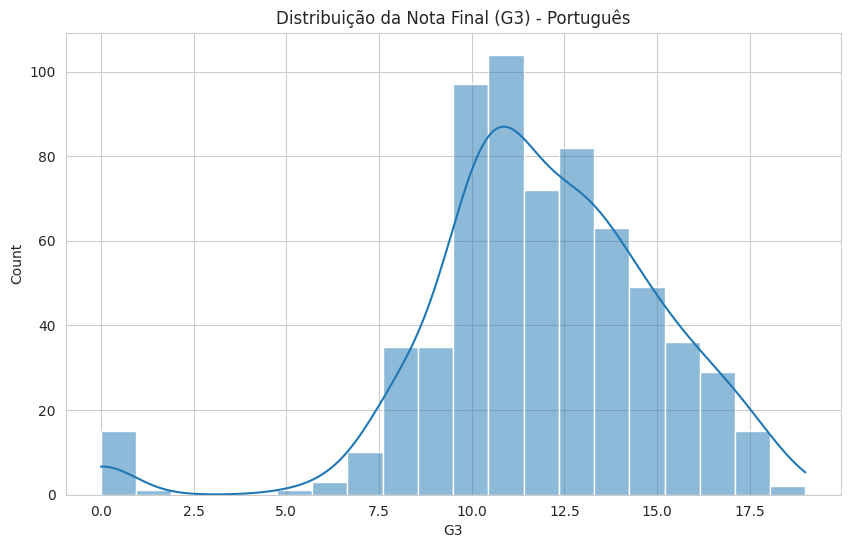

In [11]:
sns.histplot(port_df['G3'], bins=20, kde=True)
plt.title("Distribuição da Nota Final (G3) - Português")
plt.show()

## Relação álcool x desempenho

### Português

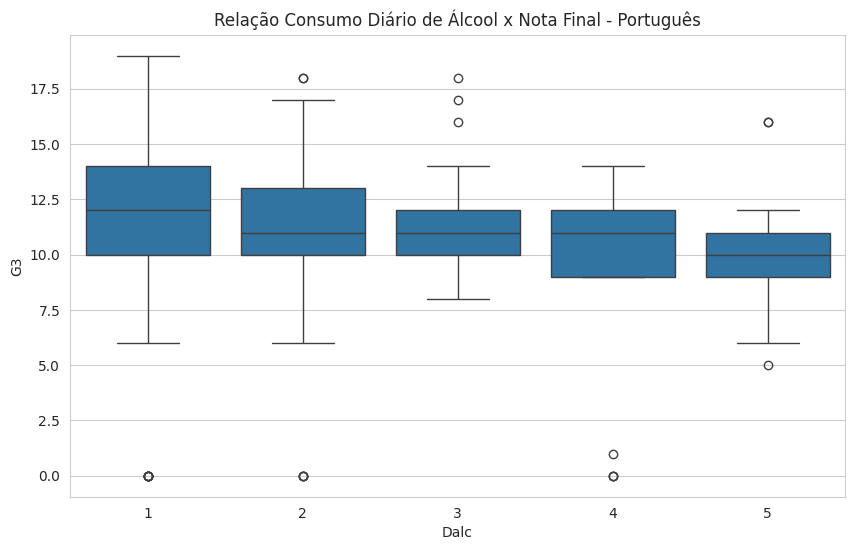

In [13]:
sns.boxplot(x='Dalc', y='G3', data=port_df)
plt.title("Relação Consumo Diário de Álcool x Nota Final - Português")
plt.show()

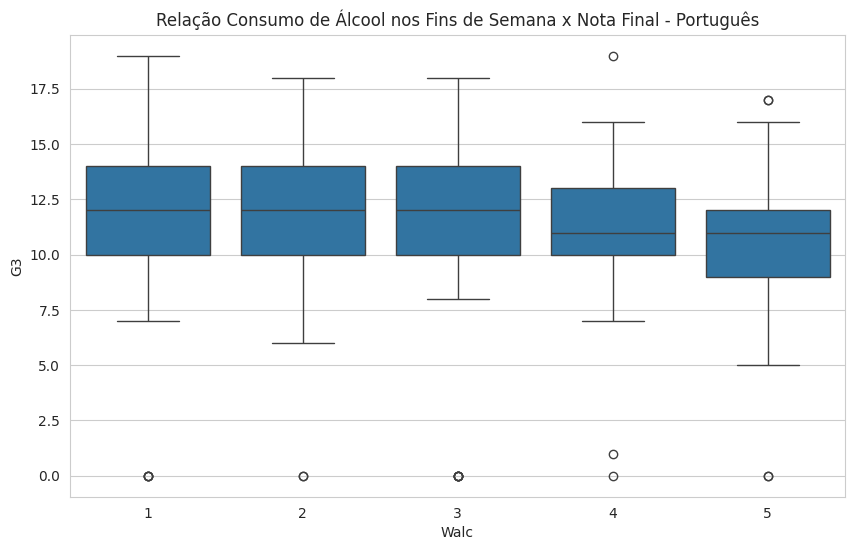

In [15]:
sns.boxplot(x='Walc', y='G3', data=port_df)
plt.title("Relação Consumo de Álcool nos Fins de Semana x Nota Final - Português")
plt.show()

### Matemática

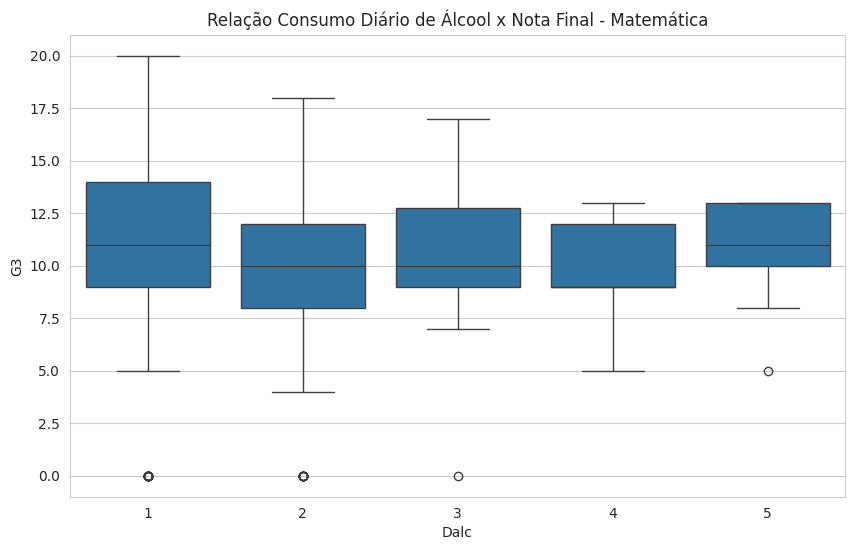

In [18]:
sns.boxplot(x='Dalc', y='G3', data=math_df)
plt.title("Relação Consumo Diário de Álcool x Nota Final - Matemática")
plt.show()

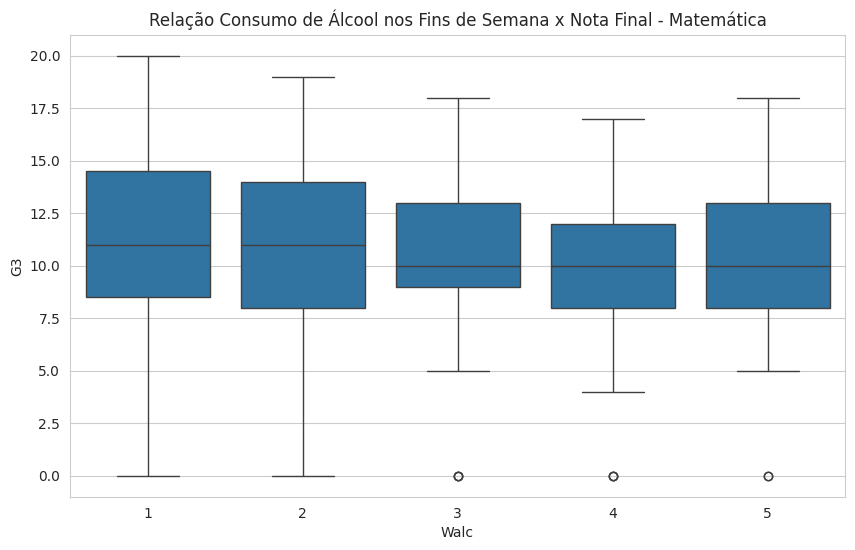

In [19]:
sns.boxplot(x='Walc', y='G3', data=math_df)
plt.title("Relação Consumo de Álcool nos Fins de Semana x Nota Final - Matemática")
plt.show()

## Desempenho x Tempo de Estudo

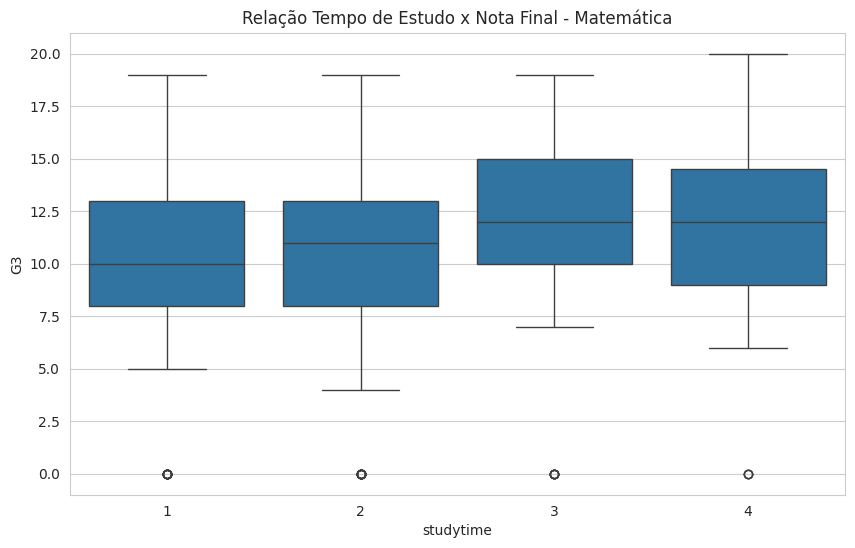

In [21]:
sns.boxplot(x='studytime', y='G3', data=math_df)
plt.title("Relação Tempo de Estudo x Nota Final - Matemática")
plt.show()

## Correlação

### Português

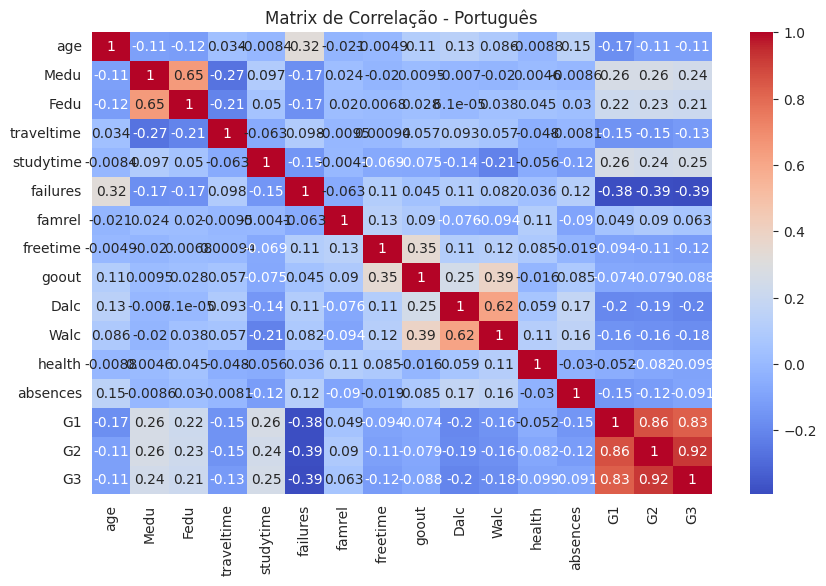

In [17]:
numeric_port_df = port_df.select_dtypes(include=np.number)

corr_port = numeric_port_df.corr()

sns.heatmap(corr_port, cmap='coolwarm', annot=True)
plt.title("Matrix de Correlação - Português")
plt.show()

### Matemática

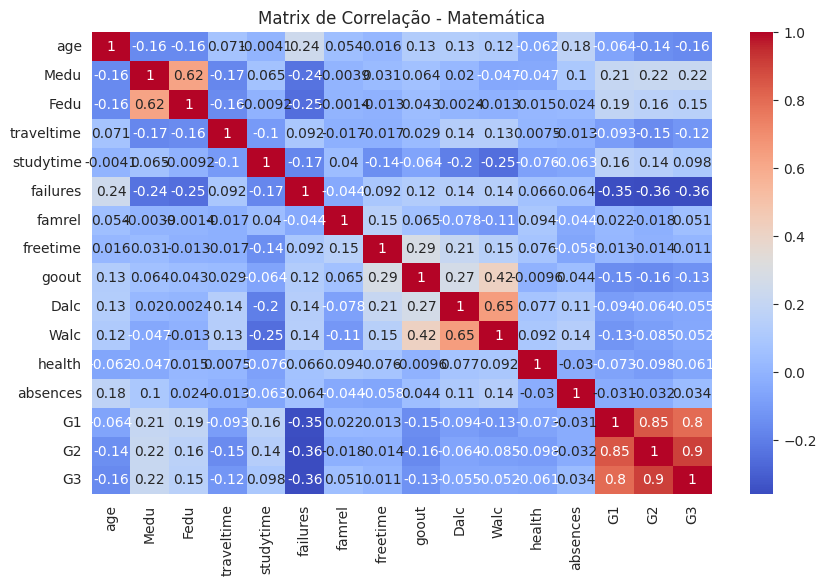

In [20]:
numeric_math_df = math_df.select_dtypes(include=np.number)

corr_math = numeric_math_df.corr()

sns.heatmap(corr_math, cmap='coolwarm', annot=True)
plt.title("Matrix de Correlação - Matemática")
plt.show()

## Conclusões iniciais

- Relação **negativa**, mas fraca a moderada entre consumo de alcool x desepenho.

- Reprovações anteriores (failures) parece indicar desempenho menor.

- Quanto mais tempo de estudo (studytime) melhor o desempenho, mas não garante notas altas.

- A educação dos pais, no contexto familiar, influencia positivamente o desempenho (correlação moderada).


As matrixes de correlação indicam que o desempenho acadêmico prévio (G1 e G2) é o principal preditor da nota final (G3). Variáveis comportamentais como consumo de álcool e tempo de estudo apresentam correlação moderada, enquanto o histórico de reprovações se destaca como um fator negativo para o desempenho.
Esses resultados indicam a necessidade de avaliar diferentes cenários de modelagem para aumentar a interpretabilidade do modelo.